# 🔥 Block 3.2 — Activation Functions

Activation functions are one of the most important parts of neural networks because they introduce **non-linearity**, allowing the network to learn complex relationships.

---

# 1. Why Do We Need Activation Functions?

A neuron first calculates:

$$
z = Wx+b
$$

If we simply stack linear layers:

$$
z_1=W_1x+b_1
$$

and

$$
z_2=W_2z_1+b_2
$$

Substitute:

$$
z_2=W_2(W_1x+b_1)+b_2
$$

$$
z_2=W_2W_1x+W_2b_1+b_2
$$

We can simplify:

$$
W'=W_2W_1
$$

$$
b'=W_2b_1+b_2
$$

Therefore:

$$
z_2=W'x+b'
$$

So:

> **Linear + Linear + Linear = Still Linear**

Even if we build 100 linear layers, mathematically they can collapse into one linear transformation.

### Activation functions break this limitation.

Instead:

$$
a_1=f(W_1x+b_1)
$$

$$
a_2=f(W_2a_1+b_2)
$$

Now the network can learn **non-linear relationships**.



### 🧠 Simple intuition

Imagine trying to draw a complicated curved boundary using only a ruler.

A linear model can basically make:

> straight lines

Activation functions allow the network to **bend and transform the representation**, making complex decision boundaries possible.

---

# 2. What Exactly Does an Activation Function Do?

A neuron computes:

$$
z=Wx+b
$$

Then activation:

$$
a=f(z)
$$

So the complete neuron is:

$$
a=f(Wx+b)
$$

Think of it as:

```text
Input
  ↓
Weighted Sum
  ↓
z = Wx + b
  ↓
Activation Function
  ↓
a = f(z)
  ↓
Next Layer
```

The activation function transforms the neuron's weighted sum.

---

# 🔥 3. Binary Step Function

The step function is one of the earliest activation functions.

$$
f(z)=
\begin{cases}
1 & z\geq0\\
0 & z<0
\end{cases}
$$

Basically:

```text
z < 0  →  0
z ≥ 0  →  1
```

### Example

If:

$$
z=-2
$$

then:

$$
f(z)=0
$$

If:

$$
z=3
$$

then:

$$
f(z)=1
$$

### Problem ❌

The step function is not suitable for modern gradient-based deep learning because its derivative is zero almost everywhere and isn't useful for smooth gradient-based optimization.

That's why modern neural networks generally use differentiable/smoother activations.

---

# 🔥 4. Sigmoid

The sigmoid function is:
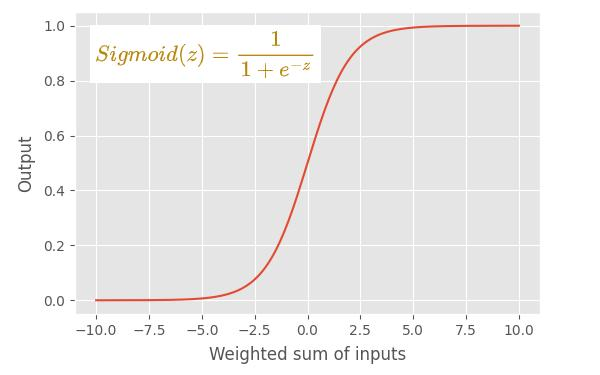

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

Its output lies between:

$$
0<\sigma(z)<1
$$



### Intuition

It takes any number and squeezes it into approximately:

```text
0 ─────────────── 1
```

Examples:

$$
\sigma(0)=0.5
$$

$$
\sigma(5)\approx0.993
$$

$$
\sigma(-5)\approx0.007
$$

### Why useful?

For binary classification:

```text
0 → class 0
1 → class 1
```

For example:

```text
Input image
     ↓
 Neural Network
     ↓
   logit = 2.5
     ↓
 Sigmoid
     ↓
  probability ≈ 0.924
```

The model can interpret this as approximately **92.4% probability** for the positive class.

---

## Sigmoid Derivative

Very important:

$$
\sigma'(z)=\sigma(z)(1-\sigma(z))
$$

The maximum derivative occurs around:

$$
\sigma(0)=0.5
$$

and the maximum slope is:

$$
0.25
$$

When $z$ becomes very positive or very negative, the derivative approaches zero.

---

## ⚠️ Sigmoid Problem — Vanishing Gradient

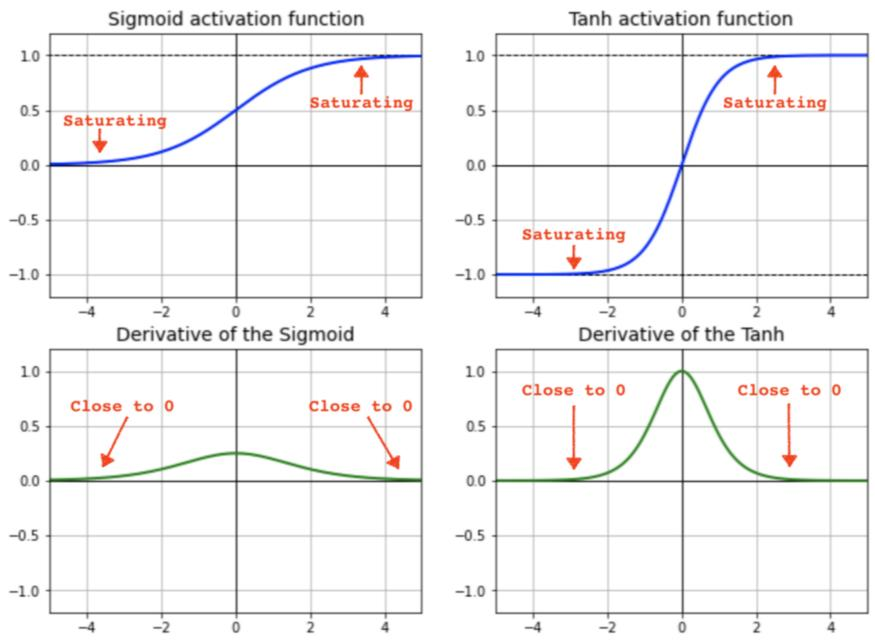
Suppose:

$$
z\rightarrow+\infty
$$

Then:

$$
\sigma(z)\rightarrow1
$$

Therefore:

$$
\sigma'(z)\rightarrow0
$$

Similarly:

$$
z\rightarrow-\infty
$$

Then:

$$
\sigma(z)\rightarrow0
$$

and:

$$
\sigma'(z)\rightarrow0
$$

So gradients can become extremely small.

This is called the:

> **Vanishing Gradient Problem**



### Practical takeaway

**Sigmoid → very common for binary output, but generally not the default hidden-layer activation in modern deep networks.**

---

# 🔥 5. Tanh

Tanh = hyperbolic tangent.

$$
\tanh(z)=\frac{e^z-e^{-z}}{e^z+e^{-z}}
$$

Output range:

$$
-1<\tanh(z)<1
$$

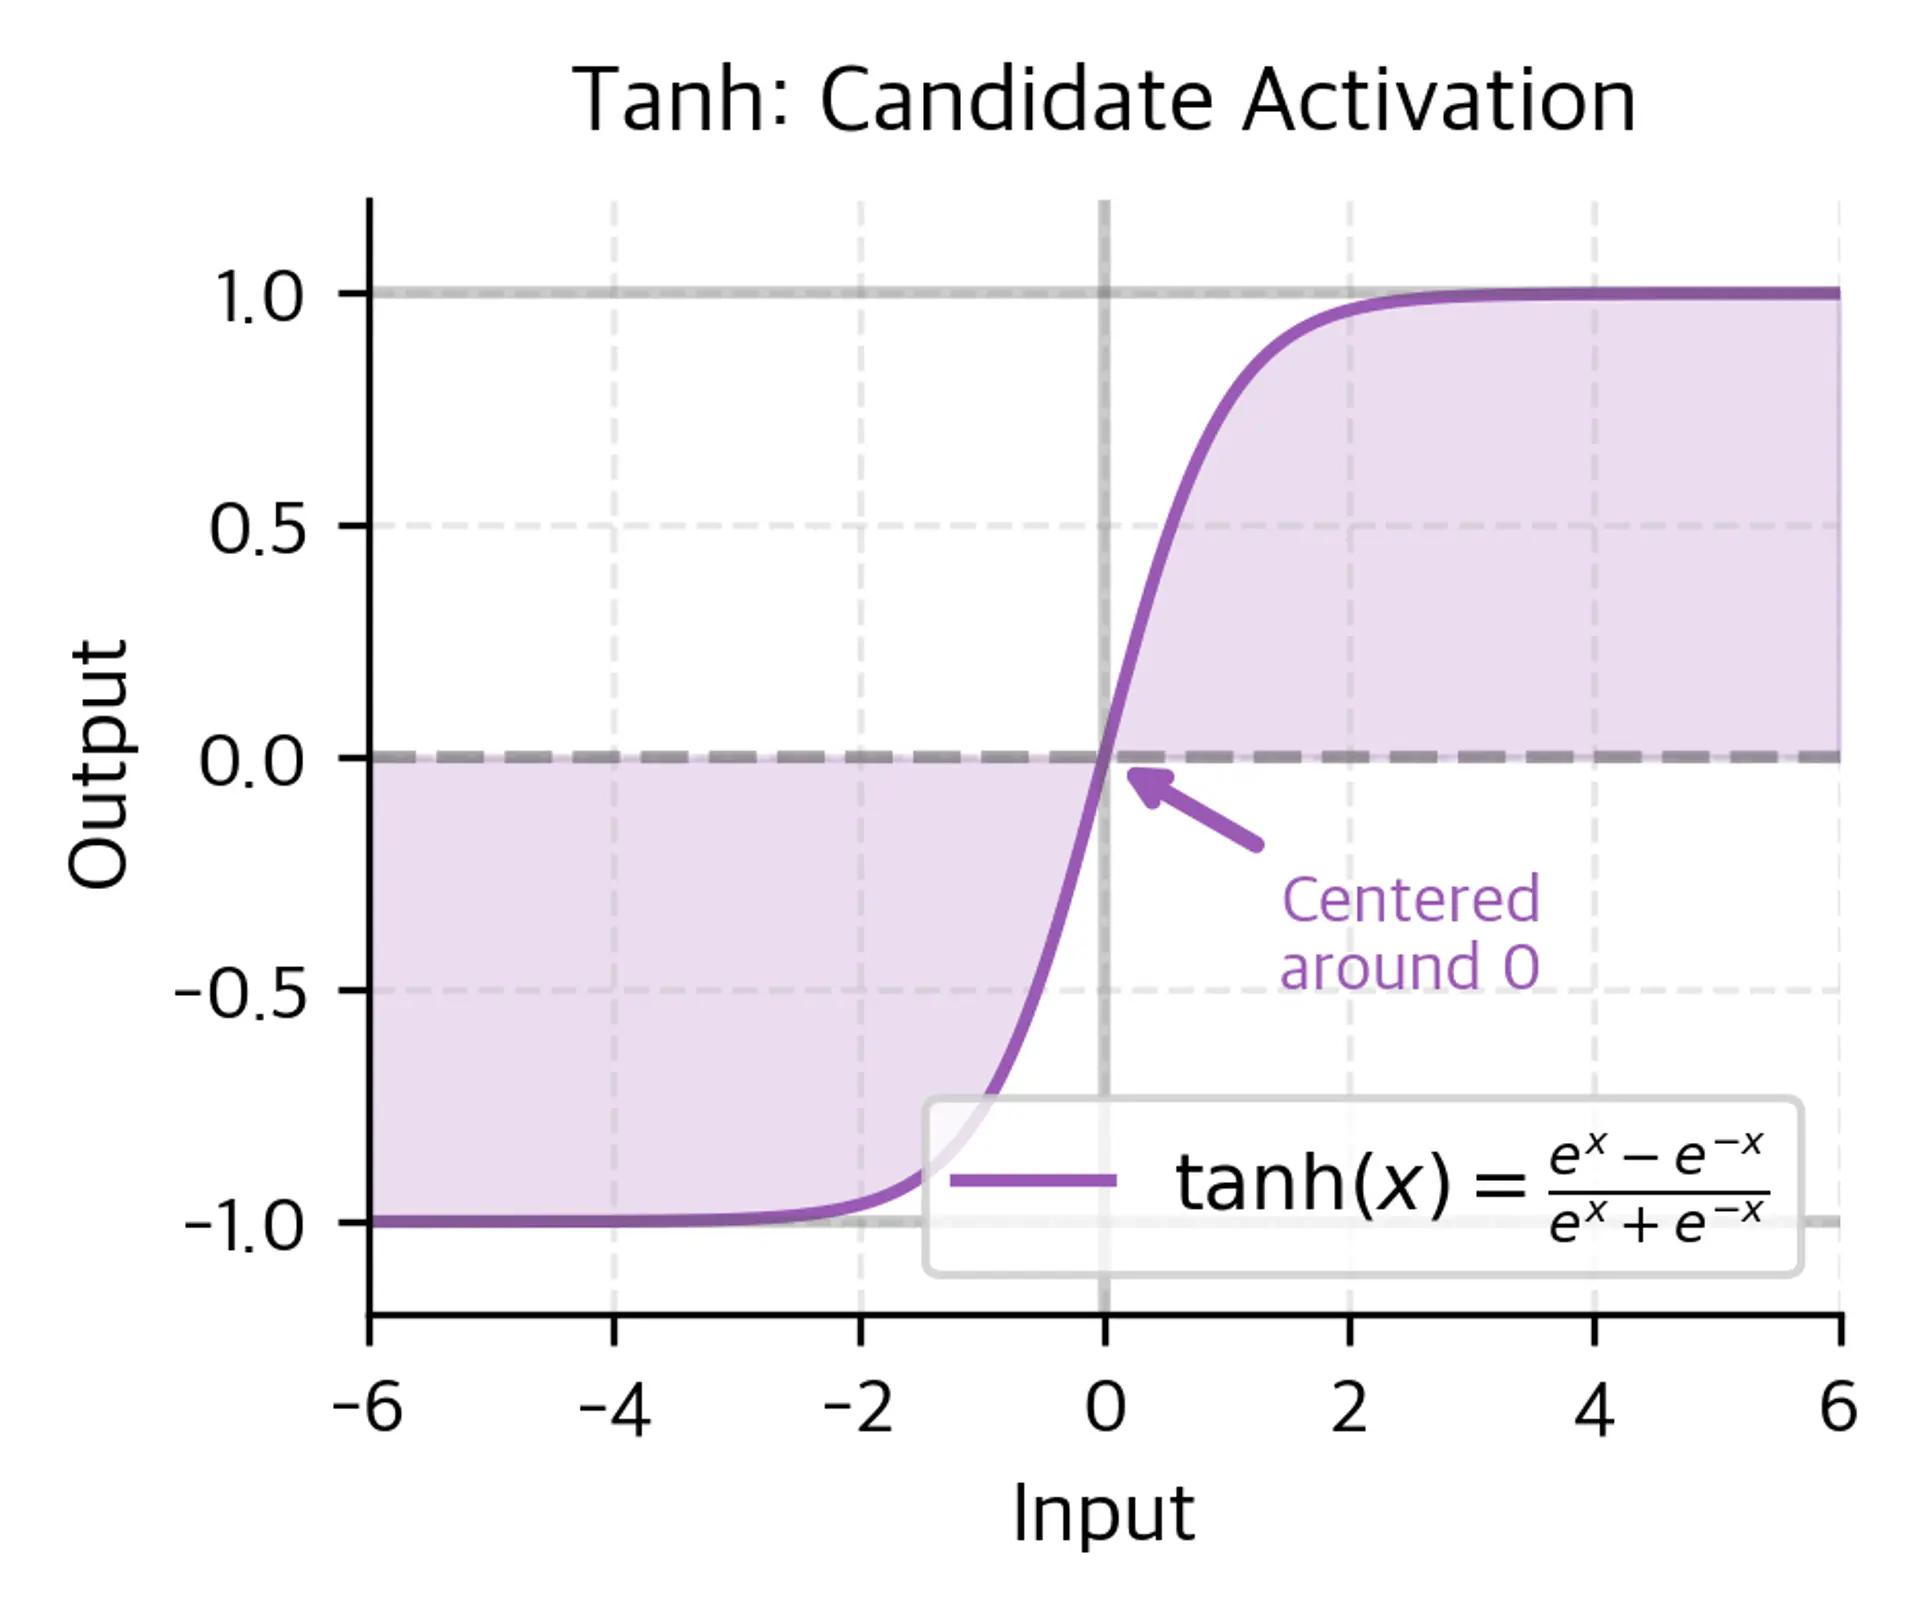

### Examples

$$
\tanh(0)=0
$$

Large positive value:

$$
\tanh(z)\rightarrow1
$$

Large negative value:

$$
\tanh(z)\rightarrow-1
$$

---

## Why Tanh was an improvement over Sigmoid

Sigmoid:

$$
(0,1)
$$

Tanh:

$$
(-1,1)
$$

So tanh is **zero-centered**.

That's useful because activations can represent both positive and negative values.

---

## Tanh derivative

$$
\tanh'(z)=1-\tanh^2(z)
$$

Again, when the function saturates at approximately $-1$ or $1$:

$$
\tanh'(z)\rightarrow0
$$

So tanh can also suffer from:

> **Vanishing gradients**

### Practical takeaway

Tanh is important to understand historically and still appears in some architectures, particularly recurrent-network contexts, but it isn't generally the default activation for modern hidden layers.

---

# 🔥 6. ReLU

Now we reach one of the **most important activation functions in deep learning**.

ReLU:

> **Rectified Linear Unit**

Formula:

$$
f(z)=\max(0,z)
$$

or:

$$
f(z)=
\begin{cases}
0 & z<0\\
z & z\geq0
\end{cases}
$$

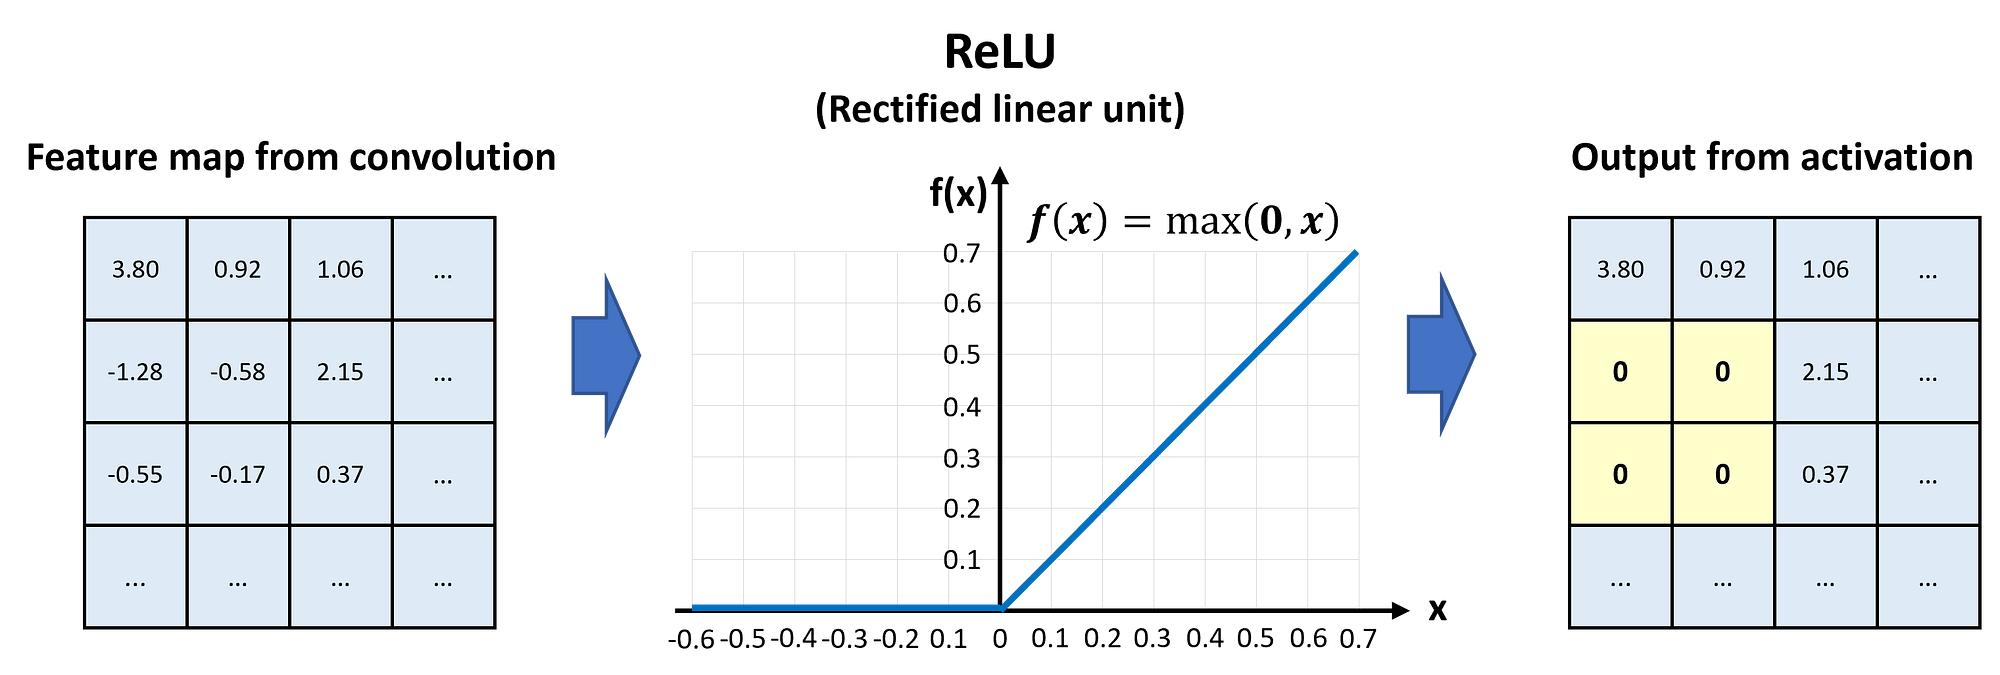

### Behavior

```text
Negative input → 0

Positive input → same value
```

Example:

$$
ReLU(-5)=0
$$

$$
ReLU(-2)=0
$$

$$
ReLU(0)=0
$$

$$
ReLU(3)=3
$$

$$
ReLU(10)=10
$$

---

# Why ReLU became so popular

### 1. Simple

Just:

$$
\max(0,z)
$$

### 2. Computationally cheap

No exponential calculation like sigmoid/tanh.

### 3. Positive region has strong gradient

For positive values:

$$
f'(z)=1
$$

This helps gradient flow compared with saturated sigmoid/tanh regions.

### 4. Sparse activations

Negative inputs become zero.

Example:

```text
Before ReLU:

[-3, 2, -1, 5, -7, 4]

After ReLU:

[ 0, 2,  0, 5,  0, 4]
```

This can create sparse representations.

---

# ⚠️ Dying ReLU Problem

Here's the major weakness.

For:

$$
z<0
$$

ReLU outputs:

$$
0
$$

and its derivative is:

$$
0
$$

If a neuron repeatedly receives negative inputs, its gradient can remain zero.

The neuron can effectively stop learning.

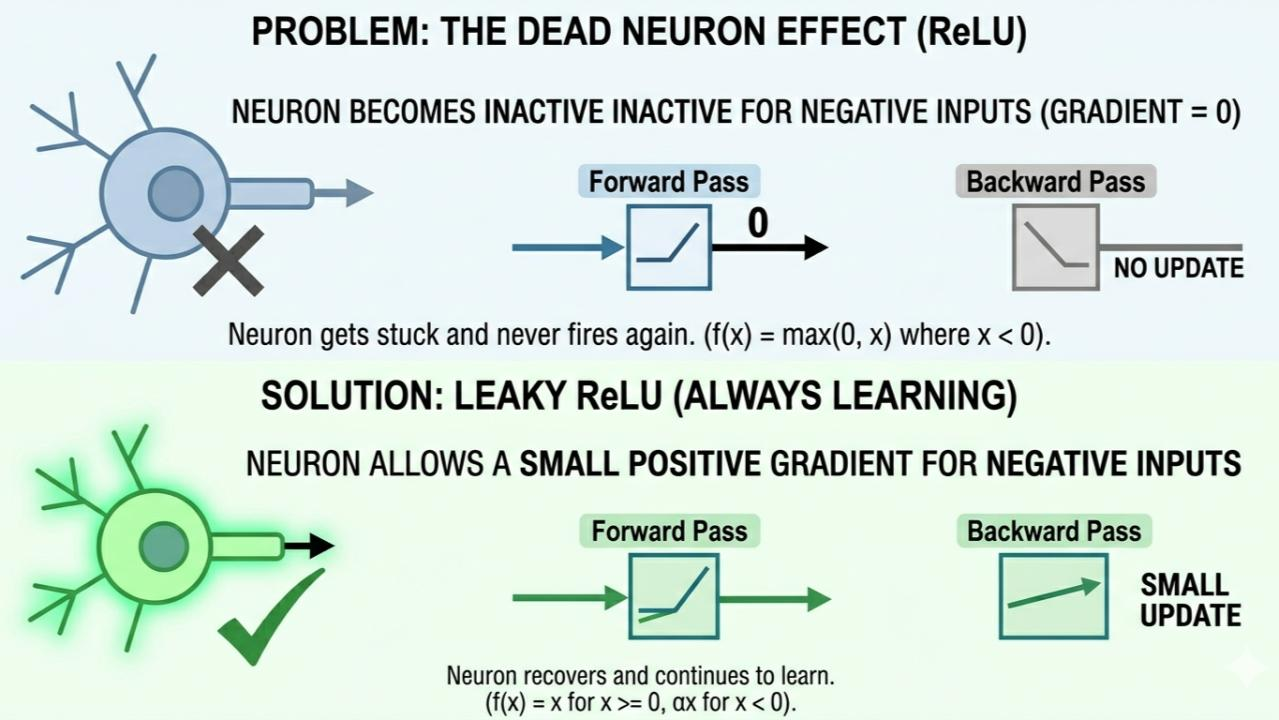

This is called:

> **Dying ReLU**



---

# 🔥 7. Leaky ReLU

Leaky ReLU was introduced to reduce the dying-ReLU issue.

Formula:

$$
f(z)=
\begin{cases}
z & z>0\\
\alpha z & z\leq0
\end{cases}
$$

Usually:

$$
\alpha=0.01
$$

as an example.

So:

```text
Positive → normal slope

Negative → small negative slope
```
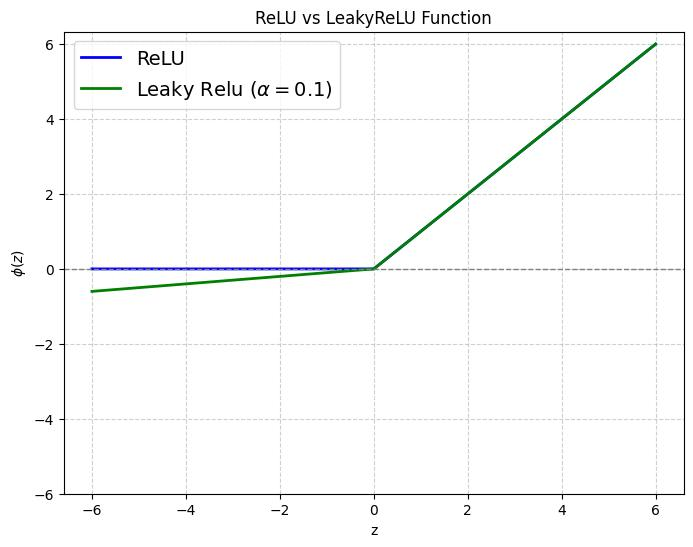

Example:

$$
z=-5
$$

ReLU:

$$
ReLU(-5)=0
$$

Leaky ReLU:

$$
LeakyReLU(-5)=0.01(-5)=-0.05
$$

So the neuron still has a small gradient on the negative side.



### Main idea

```text
ReLU:

negative → 0

Leaky ReLU:

negative → small negative value
```

### Why?

To allow some gradient to flow through the negative region.

---

# 🔥 8. ELU

ELU:

> Exponential Linear Unit

Formula:

$$
f(z)=
\begin{cases}
z & z>0\\
\alpha(e^z-1) & z\leq0
\end{cases}
$$

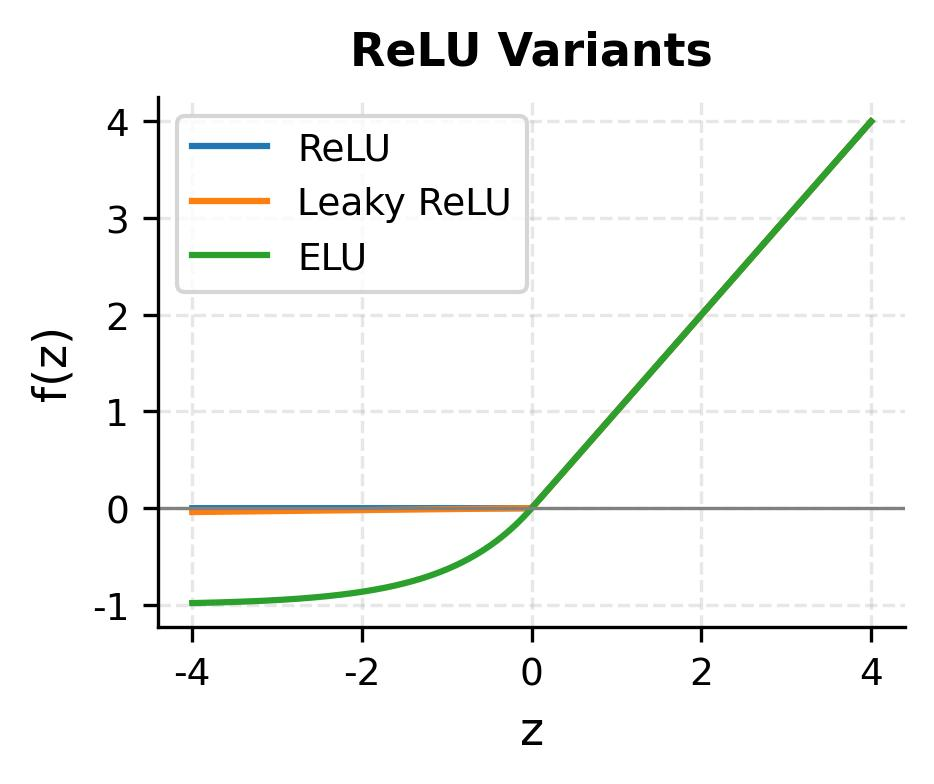

### Positive region

Same basic behavior as ReLU:

$$
f(z)=z
$$

### Negative region

Instead of becoming exactly zero, it smoothly approaches:

$$
-\alpha
$$

as $z$ becomes very negative.

### Why use it?

It provides a smooth negative region and can reduce some issues associated with standard ReLU.

But it is more computationally expensive because of the exponential.

### For your roadmap

You should:

> **Understand ELU conceptually.**

You don't need to spend huge amounts of time memorizing its exact behavior.

---

# 🔥 9. GELU

Now we reach a very important modern activation.

> **GELU = Gaussian Error Linear Unit**

It is especially important because you will encounter it in **Transformer architectures**.

The exact formula is:

$$
GELU(x)=x\Phi(x)
$$

where $\Phi(x)$ is the standard normal cumulative distribution function.

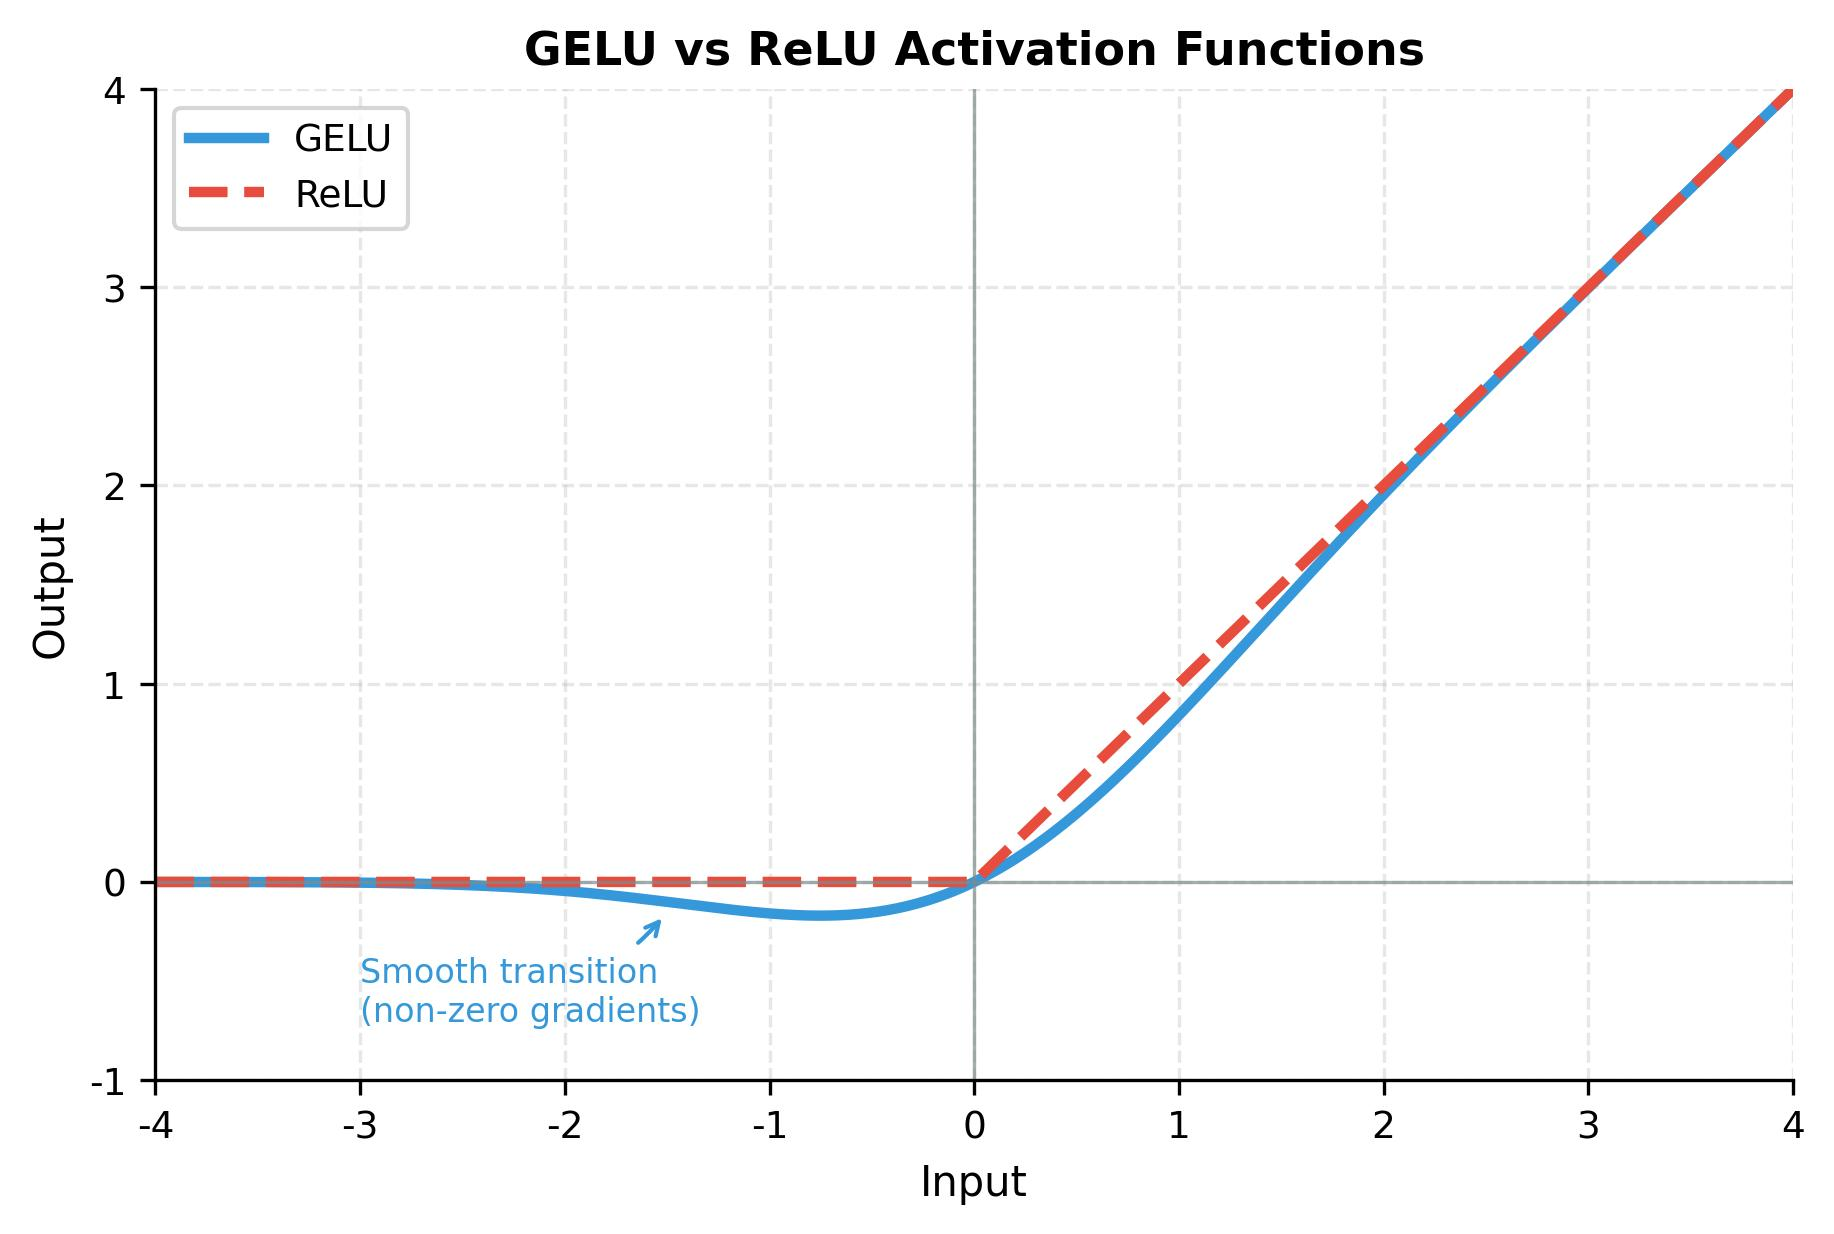

A common approximation is:

$$
GELU(x)\approx
\frac{x}{2}
\left[
1+
\tanh
\left(
\sqrt{\frac{2}{\pi}}
(x+0.044715x^3)
\right)
\right]
$$

### 🚨 Don't memorize the approximation.

For your goal, understand:

> **GELU is a smooth activation that behaves somewhat like a soft version of ReLU.**



---

## ReLU vs GELU intuition

ReLU essentially says:

```text
x < 0 → completely remove it
x > 0 → keep it
```

GELU behaves more like:

```text
Negative → smoothly suppress
Near zero → smoothly transition
Positive → increasingly preserve
```

So GELU provides a **smooth gating behavior** rather than ReLU's hard cutoff.

---

## Where is GELU important?

Especially:

- Transformers
- BERT-style models
- Vision Transformers
- Modern neural network architectures

So for your AI/ML career:

> 🔥 **GELU is definitely worth understanding.**

---

# 🔥 10. Softmax

Softmax is different from the other activations we've discussed.

It is primarily used to convert a vector of logits into a probability distribution for **mutually exclusive multiclass classification**.

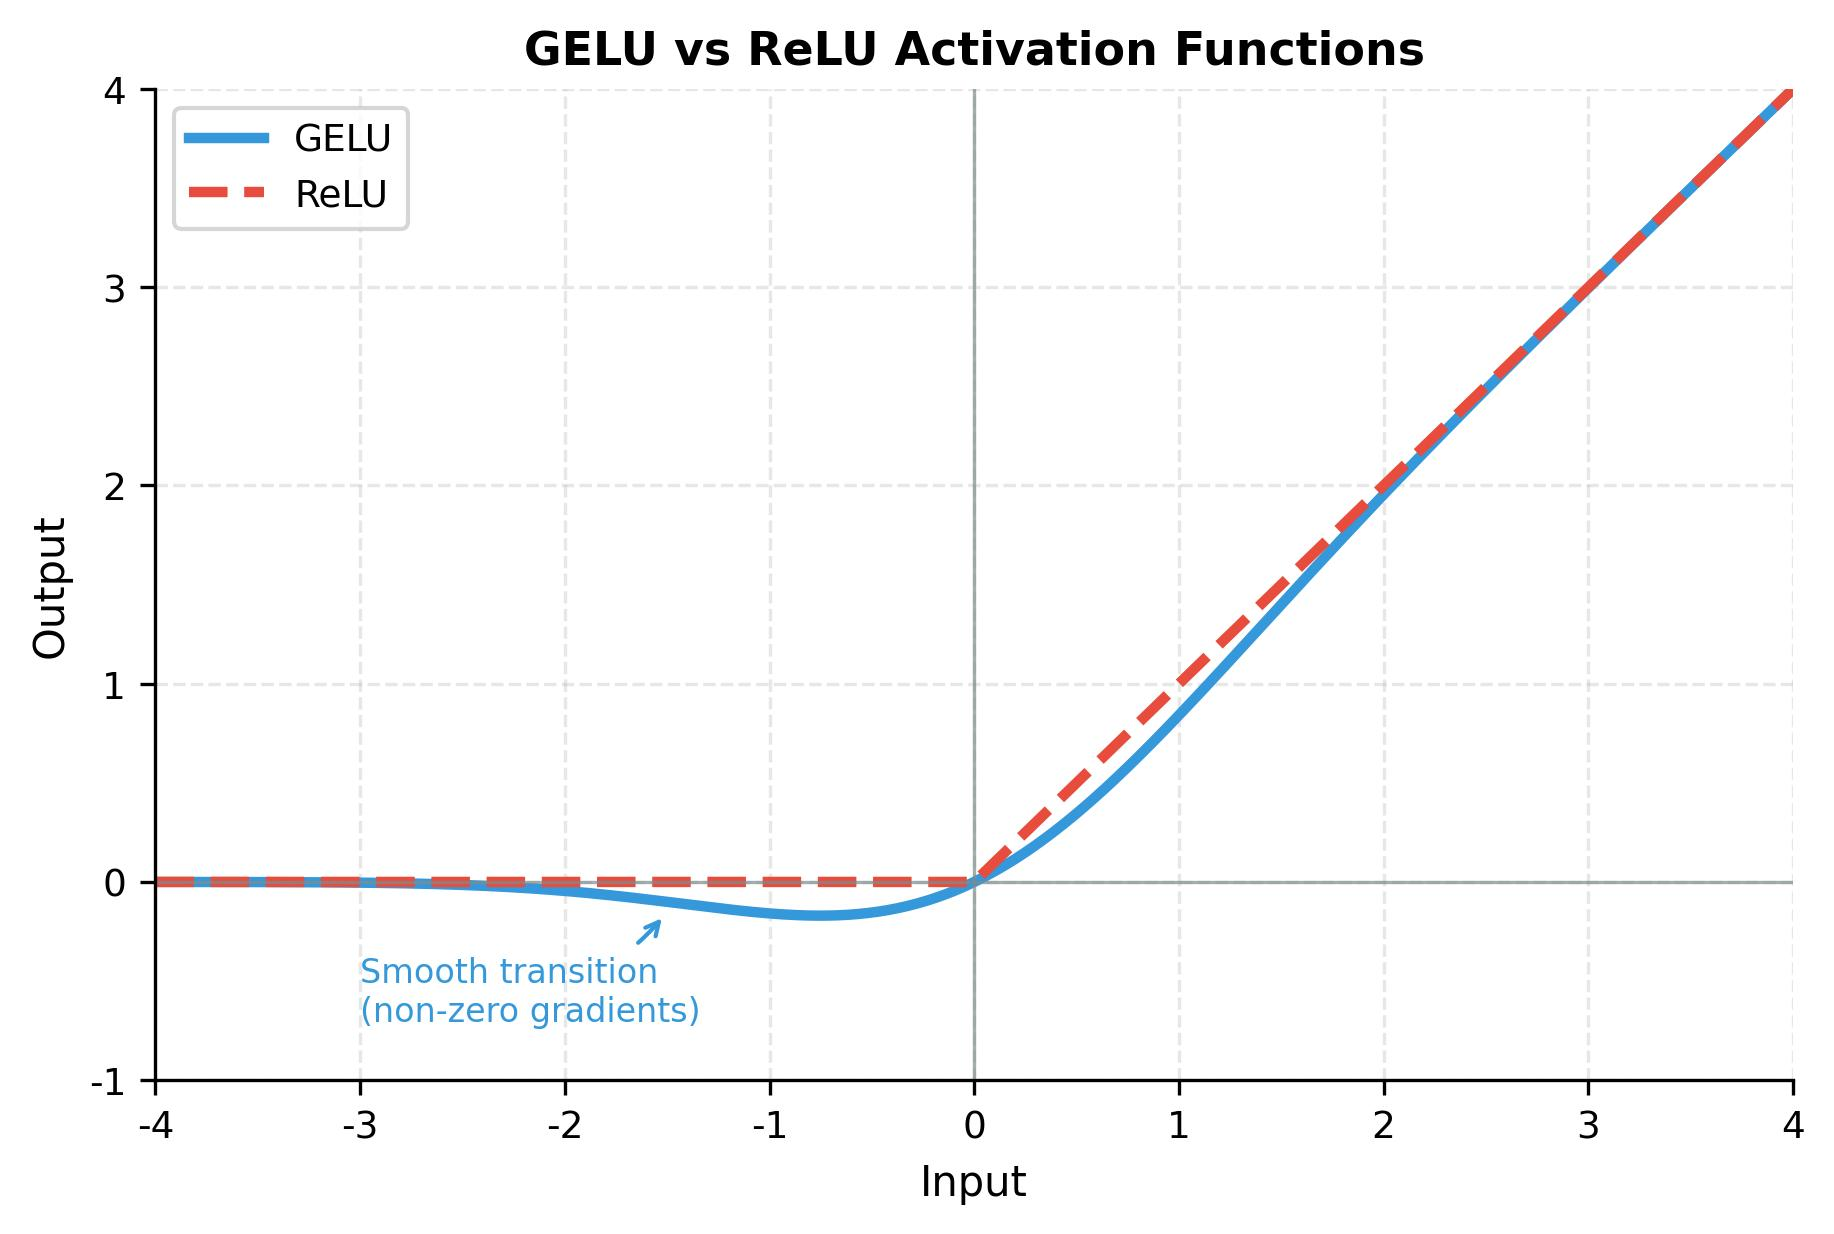

Formula:

$$
P_i=
\frac{e^{z_i}}
{\sum_{j=1}^{K}e^{z_j}}
$$

Suppose the network produces:

$$
z=[2,1,0]
$$

Softmax converts these logits into probabilities approximately:

$$
[0.665,\;0.245,\;0.090]
$$

Notice:

$$
0.665+0.245+0.090\approx1
$$



---

# 🧠 Why Does Softmax Do This?

Suppose we have:

```text
Cat    → 2.0
Dog    → 1.0
Horse  → 0.0
```

These are **logits**, not probabilities.

Softmax transforms them into something like:

```text
Cat    → 66.5%
Dog    → 24.5%
Horse  →  9.0%
```

The outputs compete with each other.

That's why:

> **Softmax → mutually exclusive multiclass classification**

---

# ⚠️ Softmax vs Sigmoid

This is VERY important.

### Multiclass

Example:

```text
Image = ?
Cat
Dog
Horse
```

Only one is correct.

Use:

$$
\boxed{\text{Softmax}}
$$

Conceptually:

```text
Cat   0.70
Dog   0.20
Horse 0.10
```

Sum:

$$
1.0
$$

---

### Multi-label

Example:

```text
Image contains:
☑ Dog
☑ Car
☑ Person
```

Multiple labels can be true.

Use:

$$
\boxed{\text{Independent\ Sigmoids}}
$$

Example:

```text
Dog     → 0.92
Car     → 0.81
Person  → 0.73
```

They don't need to sum to 1.

---

# 🔥 11. Numerical Stability of Softmax

There is an important practical trick.

Instead of:

$$
\frac{e^{z_i}}{\sum_j e^{z_j}}
$$

we can subtract the maximum logit:

$$
P_i=
\frac{e^{z_i-\max(z)}}
{\sum_j e^{z_j-\max(z)}}
$$

This gives the same result mathematically but helps prevent numerical overflow.

You don't need to manually implement this when using mature deep-learning libraries; they handle numerical stability appropriately.

---

# 🧠 12. Complete Activation Function Comparison

| Activation | Output Range | Main Characteristic | Typical Use |
|---|---|---|---|
| **Step** | 0, 1 | Hard threshold | Classical perceptron |
| **Sigmoid** | (0, 1) | Smooth S-curve | Binary output |
| **Tanh** | (-1, 1) | Zero-centered S-curve | Selected/recurrent contexts |
| **ReLU** | [0, ∞) | Zero negative values | Common hidden layers |
| **Leaky ReLU** | (-∞, ∞) | Small negative slope | ReLU alternative |
| **ELU** | (-α, ∞) | Smooth negative region | ReLU alternative |
| **GELU** | Approximately (-0.17, ∞) | Smooth gating | Transformers/modern architectures |
| **Softmax** | 0–1 | Probability distribution | Multiclass output |

---

# 🔥 13. The Most Important Selection Rule

Don't memorize:

> "Activation X is always the best."

Instead understand:

## Hidden layers

Common choices:

```text
Basic MLP
   ↓
ReLU

Modern Transformer-style model
   ↓
GELU / related smooth activations
```

## Output layer

### Regression

```text
Linear / no activation
```

### Binary classification

```text
Sigmoid conceptually
```

### Multiclass classification

```text
Softmax conceptually
```

### Multi-label classification

```text
Independent sigmoid for each output
```

---

# 🔥 14. Activation + Loss Connection

This is extremely important for your future PyTorch implementation.

## Regression

```text
Output
 ↓
Linear
 ↓
MSE / MAE / Huber
```

---

## Binary Classification

Conceptually:

```text
Output
 ↓
Sigmoid
 ↓
Probability
 ↓
Binary Cross Entropy
```

But in PyTorch, commonly:

```python
nn.BCEWithLogitsLoss()
```

This combines the sigmoid operation and BCE in a numerically stable way.

So your model normally outputs **raw logits**.

---

## Multiclass Classification

Conceptually:

```text
Output logits
 ↓
Softmax
 ↓
Probabilities
```

But in PyTorch:

```python
nn.CrossEntropyLoss()
```

expects **raw logits**.

So don't manually do:

```python
softmax → CrossEntropyLoss
```

during the normal training setup.

---

# 🧠 15. The Big Picture

Your neural network is basically:

```text
INPUT
  ↓
Linear Layer
  ↓
Activation
  ↓
Linear Layer
  ↓
Activation
  ↓
Linear Layer
  ↓
Output Activation
  ↓
PREDICTION
```

For example:

```text
Input
  ↓
Linear
  ↓
ReLU
  ↓
Linear
  ↓
ReLU
  ↓
Linear
  ↓
Sigmoid
  ↓
Binary prediction
```

The activation functions are what prevent the entire network from behaving like one giant linear equation.

---

# 🔥 16. The Core Mental Model

Remember this:

### Without activation

$$
Linear \rightarrow Linear \rightarrow Linear
$$

becomes effectively:

$$
Linear
$$

### With activation

$$
Linear \rightarrow Nonlinear \rightarrow Linear \rightarrow Nonlinear
$$

the network can learn much more complex functions.

---

# 🎯 17. What YOU Actually Need to Remember

Since you're studying for **industry-ready AI/ML**, don't waste time memorizing every tiny detail.

### 🔥🔥🔥 MUST KNOW

You should be able to explain:

- Why activation functions are needed
- Linear vs nonlinear
- Step function
- Sigmoid
- Tanh
- ReLU
- Leaky ReLU
- GELU
- Softmax
- Vanishing gradient
- Dying ReLU
- Sigmoid vs softmax
- Multiclass vs multi-label
- Hidden activation vs output activation
- Activation + loss relationship
- Why PyTorch uses logits with `CrossEntropyLoss`
- Why PyTorch uses logits with `BCEWithLogitsLoss`

### 🔥🔥 IMPORTANT

Understand:

- ELU
- Sigmoid derivative
- Tanh derivative
- ReLU derivative
- Softmax numerical stability
- GELU intuition
- Saturation

### 🔥 USEFUL

Know conceptually:

- Exact GELU approximation
- ELU mathematical behavior
- Historical reasons different activations became popular

### ➖ OPTIONAL

You don't need to spend significant time right now on:

- Memorizing every activation function
- Deriving every activation from first principles
- Rare activation variants
- Research-level comparisons

---

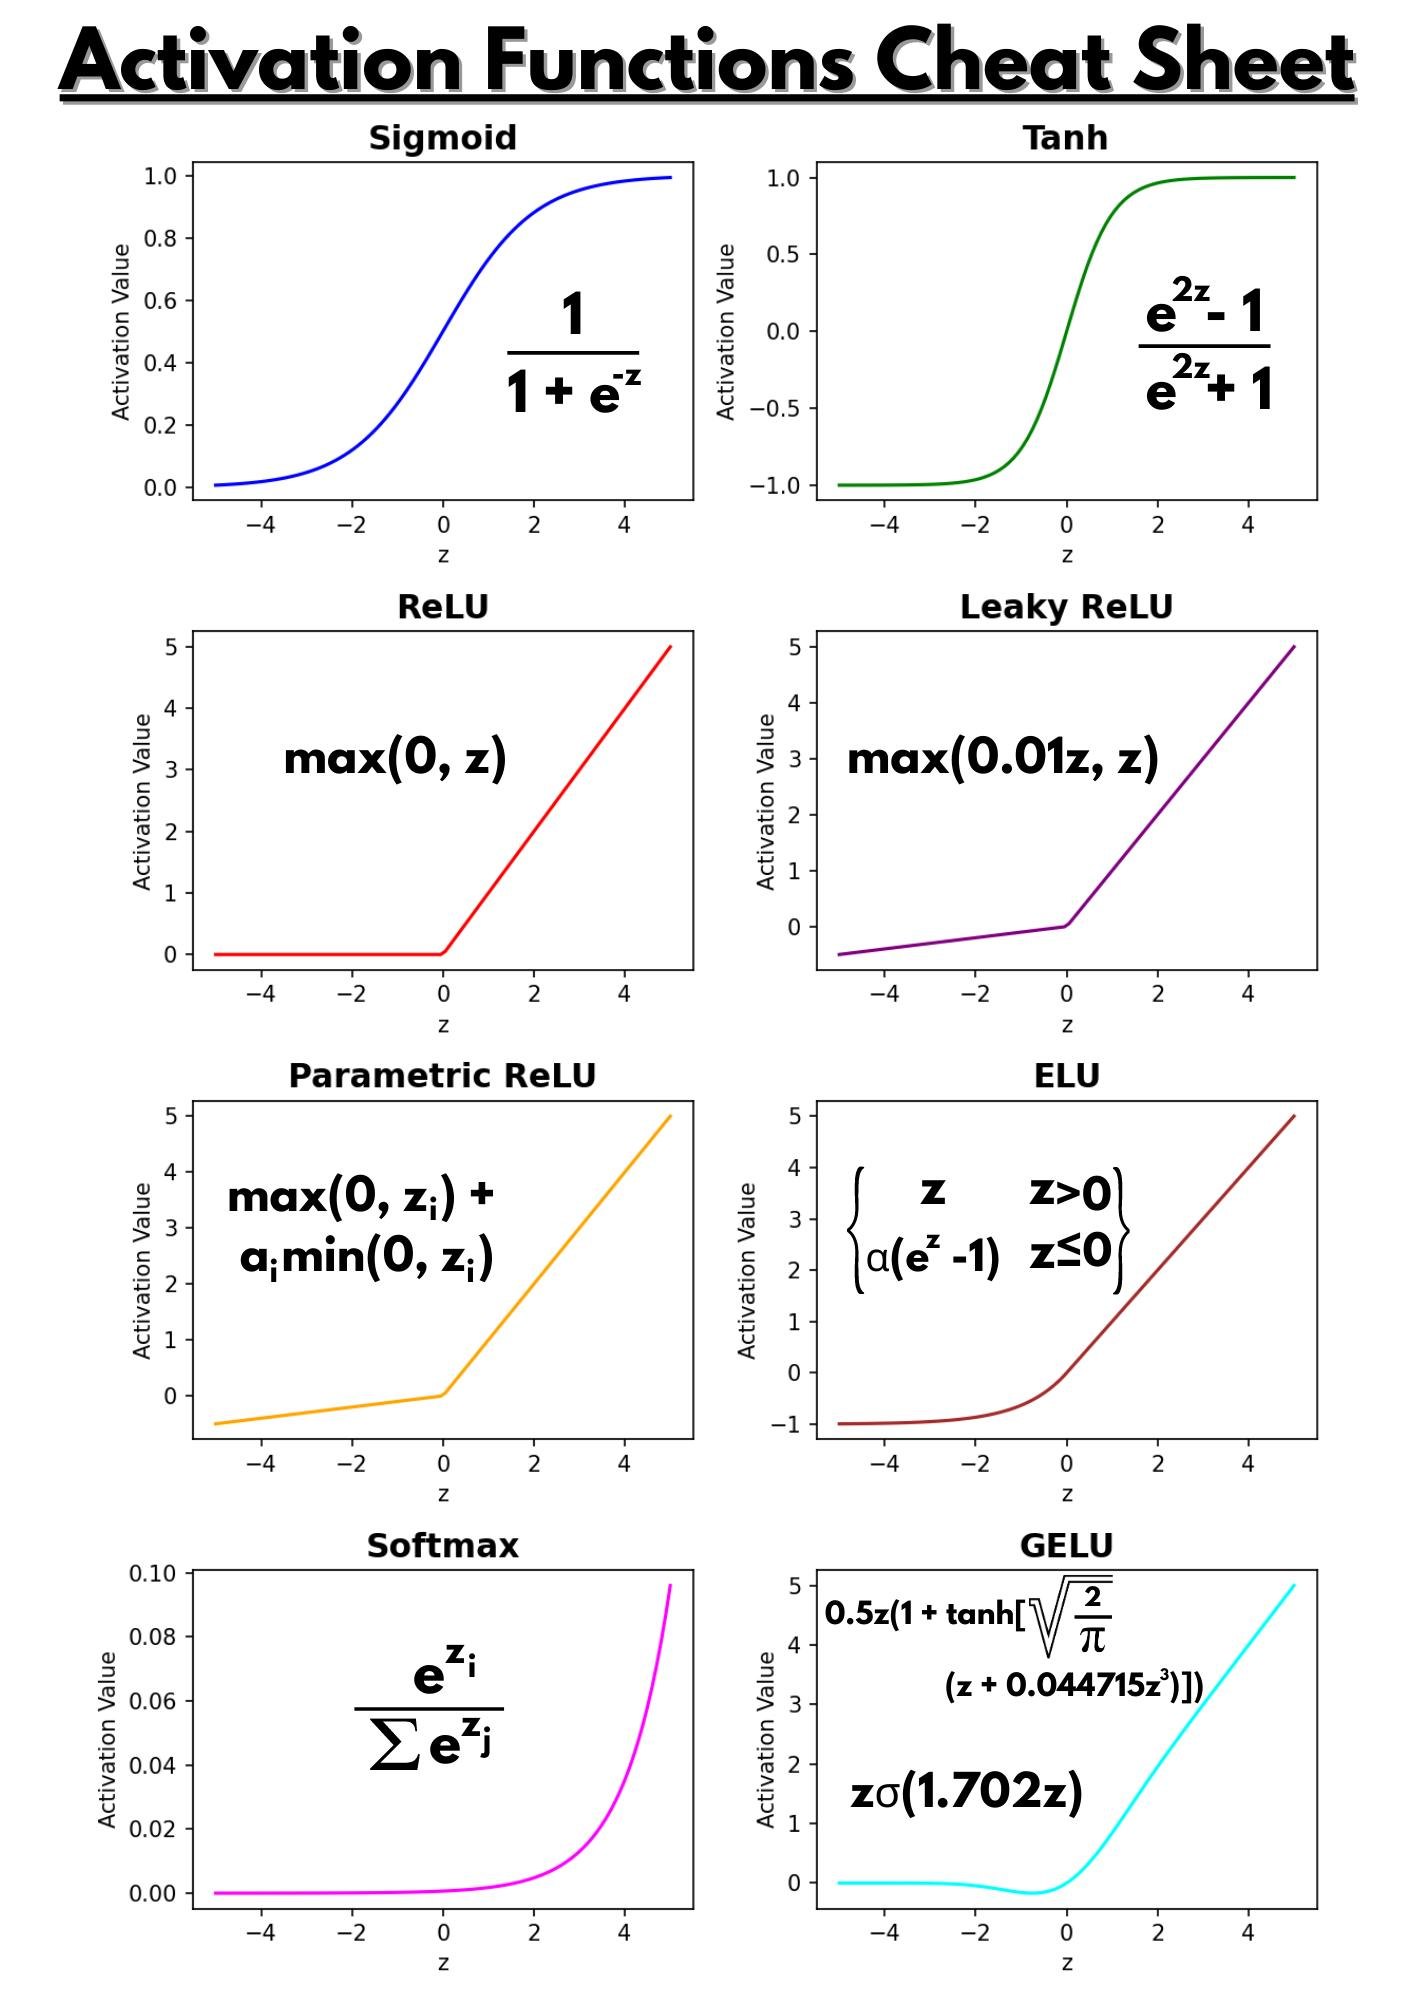

# 🧠 FINAL CHEAT SHEET

```text
STEP
↓
Hard threshold
Classical perceptron

SIGMOID
↓
0 to 1
Binary output
⚠️ Saturation / vanishing gradient

TANH
↓
-1 to +1
Zero-centered
⚠️ Saturation / vanishing gradient

RELU
↓
max(0,x)
🔥 Common hidden activation
⚠️ Dying ReLU

LEAKY ReLU
↓
Small negative slope
Reduces dying-ReLU problem

ELU
↓
Smooth negative region
ReLU alternative

GELU
↓
Smooth gating
🔥 Important in Transformers

SOFTMAX
↓
Converts logits → probability distribution
🔥 Multiclass classification
```

## 🏆 One-line memory trick

> **ReLU for common hidden layers → GELU for many Transformer-style architectures → Sigmoid for binary/multi-label outputs → Softmax for mutually exclusive multiclass outputs.**

And one more **very important PyTorch rule**:

> **`CrossEntropyLoss` → raw logits**  
> **`BCEWithLogitsLoss` → raw logits**